In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="2"  # specify which GPU(s) to be used
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os.path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import plotly
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [3]:
CTW_labelled = "/Users/chuansun/Downloads/CTW2020_labelled_data/"

In [4]:
def get_data(data_file):
    
    f = h5py.File(data_file, 'r')
    H_Re = f['H_Re'][:] #shape (sample size, 56, 924, 5)
    H_Im = f['H_Im'][:] #shape (sample size, 56, 924, 5)
    SNR = f['SNR'][:] #shape (sample size, 56, 5)
    Pos = f['Pos'][:] #shape(sample size, 3)
    f.close()
            
    return H_Re, H_Im, SNR, Pos        

# load data from file_1.hdf4

data_file = CTW_labelled+"file_"+str(1)+".hdf5"
H_Re, H_Im, SNR, Pos = get_data(data_file)
print("H_Re is of shape {}".format(H_Re.shape))
print("H_Im is of shape {}".format(H_Im.shape))
print("SNR is of shape {}".format(SNR.shape))
print("Pos is of shape {}".format(Pos.shape))

H_Re is of shape (512, 56, 924, 5)
H_Im is of shape (512, 56, 924, 5)
SNR is of shape (512, 56, 5)
Pos is of shape (512, 3)


In [5]:
# Euclidean norm
H = np.sqrt(H_Re[:,:]**2 + H_Im[:,:]**2)

In [6]:
# append SNR onto H
h1 = np.empty([512, 56, 925, 5])
for d1 in range(512):
    for d2 in range(56):
        h = H[d1][d2]
        snr = SNR[d1][d2]
        h1[d1][d2] = np.vstack((h, snr))
        
h1.shape

(512, 56, 925, 5)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fbe5fab0c88>,
 'caps': [<matplotlib.lines.Line2D at 0x7fbe5fac0390>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fbe5fab0978>],
 'medians': [<matplotlib.lines.Line2D at 0x7fbe5fac0a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fbe5fac0dd8>],
 'means': []}

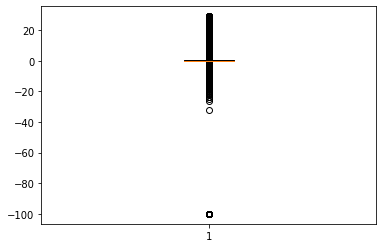

In [23]:
flatten = h1.reshape(-1)
plt.boxplot(flatten)

In [7]:
h1[:, 0, :].shape

(512, 925, 5)

In [ ]:
# h2 = np.empty([512, 56, 66])
# for i in range(56):
#     H2[:,i,:] = pca.transform(H[:,i,:])

In [8]:
# Train test split
x_train, x_test , y_train , y_test = train_test_split(h1, Pos, test_size=0.1, random_state=42)
y_train

array([[ 159.28662567, -327.41968842,  505.9691    ],
       [ 363.90652241,    3.35819798,  500.751     ],
       [  21.48752282, -121.66348421,  508.12      ],
       ...,
       [ 110.97478973, -309.17704875,  506.0858    ],
       [ 108.81043926, -119.09477021,  507.0533    ],
       [ 154.4775817 , -370.13866653,  508.3014    ]])

In [ ]:
def create_keras_model(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(3,(5,5), input_shape=(x_train.shape[1:]), activation='relu'))
    model.add(Conv2D(6,(5,5), activation='relu'))
    model.add(Conv2D(8,(5,5), activation='relu'))
    model.add(Flatten())
    model.add(Dense(8192, activation='relu'))
    model.add(Dense(4096, activation='relu'))
    model.add(Dense(3072, activation='relu'))
    model.add(Dense(2048, activation='relu'))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_absolute_percentage_error', optimizer=opt) 
    return model

model = create_keras_model(opt=Adam(1e-3))
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist = model.fit(x_train, y_train , epochs=200, validation_data=(x_test, y_test),
                 callbacks=[earlystopper], batch_size=4, verbose=1)
#val_loss = hist.history['val_loss']